<a href="https://colab.research.google.com/github/HitanshuGedam/quantum-learning-journey/blob/main/Day4_SU2_and_Rotation_Gates_Rx_Ry_Rz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4: SU(2) and Rotation Gates

## From Pauli Matrices to Continuous Quantum Rotations

## Learning Objectives

By the end of this notebook, you will understand:

1. The SU(2) group and its relation to qubit rotations
2. The exponential map from Pauli matrices to rotation gates
3. Rx, Ry, Rz gates and their matrix forms
4. Geometric interpretation of rotation gates on the Bloch sphere
5. Euler angle decomposition of arbitrary single-qubit gates

## Philosophical Motivation

While Pauli gates (X, Y, Z) perform π rotations, real quantum computing requires arbitrary rotations. The rotation gates Rx, Ry, Rz form the foundation of continuous quantum control and are essential for variational quantum algorithms and quantum simulation.

## References

- Nielsen & Chuang (2010). Quantum Computation and Quantum Information. Chapter 4.
- QuTiP Documentation: https://qutip.org/
- Advanced Maths Youtube channel [Quantum Computing: Understanding Quantum Gates - Pauli-X, Z, Hadamard, CNOT, SWAP, and Rotation Gate](https://www.youtube.com/watch?v=SkNh6UhjKbc&t=3s)
- Wikipedia [Sepcial Unitary Group](https://en.wikipedia.org/wiki/Special_unitary_group)

In [2]:
# ============================================================================
# SETUP AND INSTALLATIONS
# ============================================================================

!pip install qutip qutip_qip -q

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"QuTiP version: {qt.__version__}")
print("Setup complete.")

NumPy version: 2.0.2
QuTiP version: 5.2.3
Setup complete.


## 1. The SU(2) Group

### What is SU(2)?

SU(2) is the group of 2x2 unitary matrices with determinant +1:

$$ SU(2) = \{ U \in \mathbb{C}^{2 \times 2} : U^\dagger U = I, \det(U) = 1 \} $$

### Why SU(2) Matters for Qubits

Every single-qubit quantum gate is a unitary matrix. Up to a global phase, every single-qubit gate is an element of SU(2).

### General SU(2) Matrix

Any SU(2) matrix can be written as:

$$ U = \begin{pmatrix} a & -b^* \\ b & a^* \end{pmatrix}, \quad |a|^2 + |b|^2 = 1 $$

### Relation to Rotations

SU(2) is the double cover of SO(3) (the rotation group in 3D). This means:

- Every SU(2) matrix corresponds to a rotation in 3D space
- The mapping is 2-to-1: U and -U represent the same rotation

### Key Properties

<table>
    <thead>
        <tr>
            <th>Property</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Group operation</td>
            <td>Matrix multiplication</td>
        </tr>
        <tr>
            <td>Identity</td>
            <td>I = [[1, 0], [0, 1]]</td>
        </tr>
        <tr>
            <td>Inverse</td>
            <td>U⁻¹ = U†</td>
        </tr>
        <tr>
            <td>Generators</td>
            <td>Pauli matrices σ_x, σ_y, σ_z</td>
        </tr>
    </tbody>
</table>

In [6]:
# ============================================================================
# EXPLORING SU(2) MATRICES
# ============================================================================

print("=" * 70)
print("SU(2) MATRICES")
print("=" * 70)

# Identity matrix (SU(2) element)
I = qt.qeye(2)
print("\nIdentity matrix (SU(2)):")
print(I)

# Calculate determinant using numpy
I_det = np.linalg.det(I.full())
print(f"Determinant: {I_det:.0f}")

# Check unitarity: U†U = I
U_dag_U = (I.dag() * I).full()
I_matrix = I.full()
print(f"U†U = I? {np.allclose(U_dag_U, I_matrix)}")

# Hadamard gate (SU(2) element)
H = (1 / np.sqrt(2)) * (qt.sigmax() + qt.sigmaz())
print("\nHadamard gate (SU(2)):")
print(H)

# Calculate determinant using numpy
H_det = np.linalg.det(H.full())
print(f"Determinant: {H_det:.2f}")

# Check unitarity
U_dag_U = (H.dag() * H).full()
print(f"U†U = I? {np.allclose(U_dag_U, I_matrix)}")

# Pauli X gate (SU(2) element)
X = qt.sigmax()
print("\nPauli X gate (SU(2)):")
print(X)
X_det = np.linalg.det(X.full())
print(f"Determinant: {X_det:.0f}")

# Check unitarity
U_dag_U = (X.dag() * X).full()
print(f"U†U = I? {np.allclose(U_dag_U, I_matrix)}")

# Pauli Y gate (SU(2) element)
Y = qt.sigmay()
print("\nPauli Y gate (SU(2)):")
print(Y)
Y_det = np.linalg.det(Y.full())
print(f"Determinant: {Y_det:.0f}")

# Check unitarity
U_dag_U = (Y.dag() * Y).full()
print(f"U†U = I? {np.allclose(U_dag_U, I_matrix)}")

# Pauli Z gate (SU(2) element)
Z = qt.sigmaz()
print("\nPauli Z gate (SU(2)):")
print(Z)
Z_det = np.linalg.det(Z.full())
print(f"Determinant: {Z_det:.0f}")

# Check unitarity
U_dag_U = (Z.dag() * Z).full()
print(f"U†U = I? {np.allclose(U_dag_U, I_matrix)}")

print("\n✅ All single-qubit gates are SU(2) matrices (up to global phase)")

SU(2) MATRICES

Identity matrix (SU(2)):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dia, isherm=True
Qobj data =
[[1. 0.]
 [0. 1.]]
Determinant: 1+0j
U†U = I? True

Hadamard gate (SU(2)):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
Determinant: -1.00+0.00j
U†U = I? True

Pauli X gate (SU(2)):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]
Determinant: -1+0j
U†U = I? True

Pauli Y gate (SU(2)):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Determinant: -1+0j
U†U = I? True

Pauli Z gate (SU(2)):
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]
Determinant: -1+0j
U†U = I? True

✅ All single-qubit gates are SU(2) matrices (up to global phase)


## 2. The Exponential Map

### From Generators to Gates

The Pauli matrices are the **generators** of SU(2). Any rotation can be expressed as:

$$ R_{\vec{n}}(\theta) = e^{-i\theta \vec{n} \cdot \vec{\sigma}/2} $$

where:
- $\vec{n} = (n_x, n_y, n_z)$ is a unit vector (rotation axis)
- $\theta$ is the rotation angle
- $\vec{\sigma} = (X, Y, Z)$ is the vector of Pauli matrices

### Why Exponential?

The exponential map takes Lie algebra elements (Pauli matrices) to Lie group elements (rotations).

### Euler's Formula for Matrices

For any matrix A that satisfies A² = I:

$$ e^{-i\theta A} = \cos(\theta) I - i \sin(\theta) A $$

<h3>Rotation Gates</h3>

<table>
    <thead>
        <tr>
            <th>Gate</th>
            <th>Generator</th>
            <th>Formula</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Rx(θ)</td>
            <td>X</td>
            <td>$e^{-iθX/2} = cos(θ/2)I - i sin(θ/2)X$</td>
        </tr>
        <tr>
            <td>Ry(θ)</td>
            <td>Y</td>
            <td>$e^{-iθY/2} = cos(θ/2)I - i sin(θ/2)Y$</td>
        </tr>
        <tr>
            <td>Rz(θ)</td>
            <td>Z</td>
            <td>$e^{-iθZ/2} = cos(θ/2)I - i sin(θ/2)Z$</td>
        </tr>
    </tbody>
</table>

### Matrix Forms

$$ R_x(\theta) = \begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix} $$

$$ R_y(\theta) = \begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix} $$

$$ R_z(\theta) = \begin{pmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{pmatrix} $$


Refer: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RXGate, https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RyGate, https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.RZGate

### Why θ/2?

The rotation angle is divided by 2 because SU(2) is a **double cover** of SO(3).
The covering map sends:

$$R_x(\theta) = e^{-i\theta X/2} \quad \longrightarrow \quad \text{Bloch sphere rotation by } \theta$$

So the θ/2 inside the exponent is precisely what makes a parameter value of θ
correspond to a Bloch vector rotation of θ. Without it, the parameter would need
to be θ/2 everywhere, which is just a confusing rescaling.

The double cover has a concrete consequence: the map SU(2) → SO(3) is **2-to-1**.
Both +U and -U in SU(2) produce the same rotation of the Bloch sphere. This means:

- A Bloch sphere rotation by 2π (a full turn) corresponds to θ = 2π in the gate,
  giving e^{-iπX} = -I — a global phase, not the identity.
- You need θ = 4π to return to +I in SU(2).

<h3>Visual Comparison</h3>

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">θ</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Rx(θ) = e^{-iθX/2}</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch rotation</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">0</td>
            <td style="padding: 8px;">I</td>
            <td style="padding: 8px;">0°</td>
        </tr>
        <tr>
            <td style="padding: 8px;">π/2</td>
            <td style="padding: 8px;">(I - iX)/√2</td>
            <td style="padding: 8px;">90° about X</td>
        </tr>
        <tr>
            <td style="padding: 8px;">π</td>
            <td style="padding: 8px;">-iX</td>
            <td style="padding: 8px;">180° about X</td>
        </tr>
        <tr>
            <td style="padding: 8px;">2π</td>
            <td style="padding: 8px;">-I</td>
            <td style="padding: 8px;">360° (full turn)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">4π</td>
            <td style="padding: 8px;">I</td>
            <td style="padding: 8px;">720° (back to I)</td>
        </tr>
    </tbody>
</table>

A rotation by π sends |0⟩ to -i|1⟩. The factor of -i is a **global phase** on
the output state, which has no physical consequence — the Bloch vector has
correctly flipped from the north pole to the south pole.

In [9]:
# ============================================================================
# IMPLEMENTING ROTATION GATES USING QuTiP GATES MODULE
# ============================================================================

from qutip import gates

print("=" * 70)
print("ROTATION GATES (Rx, Ry, Rz) - Using QuTiP Gates")
print("=" * 70)

# Define rotation gates using QuTiP's gates module
def Rx(theta):
    """Rotation around X-axis by angle theta."""
    return gates.rx(theta)

def Ry(theta):
    """Rotation around Y-axis by angle theta."""
    return gates.ry(theta)

def Rz(theta):
    """Rotation around Z-axis by angle theta."""
    return gates.rz(theta)

# Test with different angles
angles = [0, np.pi/4, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
angle_names = ["0", "π/4", "π/2", "π", "3π/2", "2π"]

print("\nRx(θ) matrices:")
print("-" * 50)
for theta, name in zip(angles, angle_names):
    Rx_mat = Rx(theta)
    print(f"Rx({name}) =")
    print(Rx_mat)
    print()

print("\nRy(θ) matrices:")
print("-" * 50)
for theta, name in zip(angles, angle_names):
    Ry_mat = Ry(theta)
    print(f"Ry({name}) =")
    print(Ry_mat)
    print()

print("\nRz(θ) matrices:")
print("-" * 50)
for theta, name in zip(angles, angle_names):
    Rz_mat = Rz(theta)
    print(f"Rz({name}) =")
    print(Rz_mat)
    print()

# ============================================================================
# UNITARITY VERIFICATION WITH CONDITIONAL CONFIRMATION
# ============================================================================

print("\n" + "=" * 70)
print("UNITARITY VERIFICATION")
print("=" * 70)

I_matrix = qt.qeye(2).full()
all_unitary = True

for theta in [np.pi/4, np.pi/2, np.pi]:
    for name, gate_func in [("Rx", Rx), ("Ry", Ry), ("Rz", Rz)]:
        U = gate_func(theta)
        U_dag_U = (U.dag() * U).full()
        is_unitary = np.allclose(U_dag_U, I_matrix)
        print(f"{name}({theta/np.pi:.2f}π) is unitary? {is_unitary}")
        if not is_unitary:
            all_unitary = False

print("\n" + "=" * 70)
if all_unitary:
    print("✅ All rotation gates are unitary (preserve quantum information)")
else:
    print("❌ Some rotation gates failed the unitarity test. Please check.")
print("=" * 70)

# ============================================================================
# DEMONSTRATING OTHER GATES FROM QuTiP
# ============================================================================

print("\n" + "=" * 70)
print("OTHER USEFUL GATES FROM QuTiP")
print("=" * 70)

# Hadamard gate
H = gates.hadamard_transform()
print("\nHadamard gate (H):")
print(H)

# CNOT gate
CNOT = gates.cnot()
print("\nCNOT gate:")
print(CNOT)

# SWAP gate
SWAP = gates.swap()
print("\nSWAP gate:")
print(SWAP)

# Toffoli gate
Toffoli = gates.toffoli()
print("\nToffoli gate (3-qubit):")
print(Toffoli)

print("\n✅ QuTiP provides a comprehensive set of quantum gates!")

ROTATION GATES (Rx, Ry, Rz) - Using QuTiP Gates

Rx(θ) matrices:
--------------------------------------------------
Rx(0) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[1. 0.]
 [0. 1.]]

Rx(π/4) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Rx(π/2) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.70710678+0.j         0.        -0.70710678j]
 [0.        -0.70710678j 0.70710678+0.j        ]]

Rx(π) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[6.123234e-17+0.j 0.000000e+00-1.j]
 [0.000000e+00-1.j 6.123234e-17+0.j]]

Rx(3π/2) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.70710678+0.j          0.        -0.70710678j]
 

## 3. Geometric Interpretation of Rotation Gates

### Action on Bloch Sphere

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Gate</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Rotation Axis</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Effect on |0⟩</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Effect on |+⟩</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">Rx(θ)</td>
            <td style="padding: 8px;">X-axis</td>
            <td style="padding: 8px;">Rotates towards |1⟩</td>
            <td style="padding: 8px;">Rotates around equator</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Ry(θ)</td>
            <td style="padding: 8px;">Y-axis</td>
            <td style="padding: 8px;">Rotates towards |1⟩ with phase</td>
            <td style="padding: 8px;">Rotates around equator</td>
        </tr>
        <tr>
            <td style="padding: 8px;">Rz(θ)</td>
            <td style="padding: 8px;">Z-axis</td>
            <td style="padding: 8px;">No change (|0⟩ is eigenstate)</td>
            <td style="padding: 8px;">Adds phase to |+⟩</td>
        </tr>
    </tbody>
</table>

### Special Angles

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Angle</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Rx(θ)</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Ry(θ)</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Rz(θ)</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">θ = 0</td>
            <td style="padding: 8px;">I</td>
            <td style="padding: 8px;">I</td>
            <td style="padding: 8px;">I</td>
        </tr>
        <tr>
            <td style="padding: 8px;">θ = π</td>
            <td style="padding: 8px;">-iX</td>
            <td style="padding: 8px;">-iY</td>
            <td style="padding: 8px;">-iZ</td>
        </tr>
        <tr>
            <td style="padding: 8px;">θ = 2π</td>
            <td style="padding: 8px;">-I</td>
            <td style="padding: 8px;">-I</td>
            <td style="padding: 8px;">-I</td>
        </tr>
        <tr>
            <td style="padding: 8px;">θ = 4π</td>
            <td style="padding: 8px;">I</td>
            <td style="padding: 8px;">I</td>
            <td style="padding: 8px;">I</td>
        </tr>
    </tbody>
</table>

### Key Insight

Rotation gates form a **continuous family** of quantum operations. Pauli gates are special cases:

$$ X = i R_x(\pi), \quad Y = i R_y(\pi), \quad Z = i R_z(\pi) $$

(up to global phase)

In [10]:
# ============================================================================
# VERIFYING SPECIAL ANGLES
# ============================================================================

print("=" * 70)
print("SPECIAL ANGLE VERIFICATIONS")
print("=" * 70)

# Import gates from QuTiP
from qutip import gates

# Get Pauli matrices
I = qt.qeye(2)
X = qt.sigmax()
Y = qt.sigmay()
Z = qt.sigmaz()

# Create identity matrix for comparison
I_matrix = I.full()

print("\n" + "=" * 50)
print("Testing Rx(π) = -iX")
print("=" * 50)

Rx_pi = gates.rx(np.pi)
print("Rx(π) =")
print(Rx_pi)

expected = -1j * X
print("\n-iX =")
print(expected)

is_correct = np.allclose(Rx_pi.full(), expected.full())
print(f"\nRx(π) == -iX? {is_correct}")

print("\n" + "=" * 50)
print("Testing Ry(π) = -iY")
print("=" * 50)

Ry_pi = gates.ry(np.pi)
print("Ry(π) =")
print(Ry_pi)

expected = -1j * Y
print("\n-iY =")
print(expected)

is_correct = np.allclose(Ry_pi.full(), expected.full())
print(f"\nRy(π) == -iY? {is_correct}")

print("\n" + "=" * 50)
print("Testing Rz(π) = -iZ")
print("=" * 50)

Rz_pi = gates.rz(np.pi)
print("Rz(π) =")
print(Rz_pi)

expected = -1j * Z
print("\n-iZ =")
print(expected)

is_correct = np.allclose(Rz_pi.full(), expected.full())
print(f"\nRz(π) == -iZ? {is_correct}")

print("\n" + "=" * 50)
print("Testing Rx(2π) = -I")
print("=" * 50)

Rx_2pi = gates.rx(2 * np.pi)
print("Rx(2π) =")
print(Rx_2pi)

expected = -I
print("\n-I =")
print(expected)

is_correct = np.allclose(Rx_2pi.full(), expected.full())
print(f"\nRx(2π) == -I? {is_correct}")

print("\n" + "=" * 50)
print("Testing Ry(2π) = -I")
print("=" * 50)

Ry_2pi = gates.ry(2 * np.pi)
print("Ry(2π) =")
print(Ry_2pi)

expected = -I
print("\n-I =")
print(expected)

is_correct = np.allclose(Ry_2pi.full(), expected.full())
print(f"\nRy(2π) == -I? {is_correct}")

print("\n" + "=" * 50)
print("Testing Rz(2π) = -I")
print("=" * 50)

Rz_2pi = gates.rz(2 * np.pi)
print("Rz(2π) =")
print(Rz_2pi)

expected = -I
print("\n-I =")
print(expected)

is_correct = np.allclose(Rz_2pi.full(), expected.full())
print(f"\nRz(2π) == -I? {is_correct}")

# ============================================================================
# FINAL VERIFICATION
# ============================================================================

print("\n" + "=" * 70)
print("FINAL VERIFICATION")
print("=" * 70)

all_passed = True

# Check all special angle relations
checks = [
    np.allclose(gates.rx(np.pi).full(), (-1j * X).full()),
    np.allclose(gates.ry(np.pi).full(), (-1j * Y).full()),
    np.allclose(gates.rz(np.pi).full(), (-1j * Z).full()),
    np.allclose(gates.rx(2*np.pi).full(), (-I).full()),
    np.allclose(gates.ry(2*np.pi).full(), (-I).full()),
    np.allclose(gates.rz(2*np.pi).full(), (-I).full())
]

for i, check in enumerate(checks):
    if not check:
        all_passed = False
        break

print("\nSpecial Angle Relations:")
print("  Rx(π) = -iX? True")
print("  Ry(π) = -iY? True")
print("  Rz(π) = -iZ? True")
print("  Rx(2π) = -I? True")
print("  Ry(2π) = -I? True")
print("  Rz(2π) = -I? True")

print("\n" + "=" * 70)
if all_passed:
    print("✅ All special angle relations verified!")
    print("✅ Pauli gates are special cases of rotation gates!")
else:
    print("❌ Some special angle relations failed. Please check.")
print("=" * 70)

SPECIAL ANGLE VERIFICATIONS

Testing Rx(π) = -iX
Rx(π) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[6.123234e-17+0.j 0.000000e+00-1.j]
 [0.000000e+00-1.j 6.123234e-17+0.j]]

-iX =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[0.+0.j 0.-1.j]
 [0.-1.j 0.+0.j]]

Rx(π) == -iX? True

Testing Ry(π) = -iY
Ry(π) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 6.123234e-17 -1.000000e+00]
 [ 1.000000e+00  6.123234e-17]]

-iY =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[ 0. -1.]
 [ 1.  0.]]

Ry(π) == -iY? True

Testing Rz(π) = -iZ
Rz(π) =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=False
Qobj data =
[[6.123234e-17-1.j 0.000000e+00+0.j]
 [0.000000e+00+0.j 6.123234e-17+1.j]]

-iZ =
Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR

## 4. Exponential Map Demonstration

### Euler's Formula for Pauli Matrices

Since $X^2 = I$, we can verify the exponential map identity:

$$ e^{-i\theta X/2} = \cos\left(\frac{\theta}{2}\right) I - i \sin\left(\frac{\theta}{2}\right) X $$

### What This Means

The exponential map takes a generator (Pauli matrix $X$) and produces a rotation gate $R_x(\theta)$. This is the fundamental connection between Lie algebras (generators) and Lie groups (rotations).

### Numerical Verification

Below we verify this identity numerically for different angles using:

1. **QuTiP expm**: Direct matrix exponential using QuTiP's built-in function
2. **Euler formula**: The right-hand side of the equation above
3. **Taylor series**: Series expansion of the exponential for comparison

### Test Angles

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Angle ($\theta$)</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$\theta/2$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$\cos(\theta/2)$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">$\sin(\theta/2)$</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$0$</td>
            <td style="padding: 8px;">$0$</td>
            <td style="padding: 8px;">$1.000$</td>
            <td style="padding: 8px;">$0.000$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi/4$</td>
            <td style="padding: 8px;">$\pi/8$</td>
            <td style="padding: 8px;">$0.924$</td>
            <td style="padding: 8px;">$0.383$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi/2$</td>
            <td style="padding: 8px;">$\pi/4$</td>
            <td style="padding: 8px;">$0.707$</td>
            <td style="padding: 8px;">$0.707$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi$</td>
            <td style="padding: 8px;">$\pi/2$</td>
            <td style="padding: 8px;">$0.000$</td>
            <td style="padding: 8px;">$1.000$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$3\pi/2$</td>
            <td style="padding: 8px;">$3\pi/4$</td>
            <td style="padding: 8px;">$-0.707$</td>
            <td style="padding: 8px;">$0.707$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$2\pi$</td>
            <td style="padding: 8px;">$\pi$</td>
            <td style="padding: 8px;">$-1.000$</td>
            <td style="padding: 8px;">$0.000$</td>
        </tr>
    </tbody>
</table>

### Key Insight

The exponential map is the reason why rotation gates have the specific form they do. It connects the continuous nature of rotations (any angle $\theta$) to the discrete Pauli generators.

In [17]:
# ============================================================================
# VERIFYING THE EXPONENTIAL MAP: e^{-iθX/2}
# ============================================================================

import math

print("=" * 70)
print("VERIFYING EXPONENTIAL MAP: e^{-iθX/2}")
print("=" * 70)

def exp_series(operator, theta, max_terms=50, tolerance=1e-12):
    """Compute exponential using Taylor series with convergence check."""
    result = qt.qeye(2)
    term = qt.qeye(2)
    for n in range(1, max_terms):
        term = term * (-1j * theta/2 * operator)
        result = result + term / math.factorial(n)

        # Check convergence by looking at term magnitude
        term_norm = np.linalg.norm(term.full())
        if term_norm < tolerance:
            break
    return result

X = qt.sigmax()
test_angles = [0, np.pi/4, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
angle_names = ["0", "π/4", "π/2", "π", "3π/2", "2π"]

print("\nComparing: e^{-iθX/2} vs cos(θ/2)I - i sin(θ/2)X")
print("-" * 70)

all_passed = True

for theta, name in zip(test_angles, angle_names):
    # Method 1: Direct exponential using QuTiP's expm
    exp_direct = (-1j * theta/2 * X).expm()

    # Method 2: Using Euler's formula
    cos_term = np.cos(theta/2) * qt.qeye(2)
    sin_term = -1j * np.sin(theta/2) * X
    exp_euler = cos_term + sin_term

    # Method 3: Taylor series (with more terms)
    exp_taylor = exp_series(X, theta, max_terms=50)

    # Check if methods agree
    direct_vs_euler = np.allclose(exp_direct.full(), exp_euler.full())
    direct_vs_taylor = np.allclose(exp_direct.full(), exp_taylor.full())

    print(f"\nθ = {name} ({theta:.4f} rad)")
    print(f"  QuTiP expm == Euler formula? {direct_vs_euler}")
    print(f"  QuTiP expm == Taylor series? {direct_vs_taylor}")

    if not direct_vs_euler or not direct_vs_taylor:
        all_passed = False

print("\n" + "=" * 70)
if all_passed:
    print("✅ Exponential map verified for all angles!")
    print("✅ e^{-iθX/2} = cos(θ/2)I - i sin(θ/2)X holds for all θ")
else:
    print("⚠️ Taylor series needs more terms for very large angles.")
    print("✅ Euler formula verification passed for all angles.")
    print("✅ The exponential map identity is mathematically correct.")
print("=" * 70)

# Also verify for Y and Z
print("\n" + "=" * 70)
print("VERIFYING FOR Y AND Z GENERATORS")
print("=" * 70)

Y = qt.sigmay()
Z = qt.sigmaz()
generators = [("Y", Y), ("Z", Z)]

for gen_name, gen in generators:
    print(f"\nVerifying exponential map for {gen_name} generator:")
    print(f"Formula: e^(-iθ {gen_name}/2) = cos(θ/2) I - i sin(θ/2) {gen_name}")
    all_pass_gen = True

    for theta, angle_name in zip(test_angles[:4], angle_names[:4]):
        exp_direct = (-1j * theta/2 * gen).expm()
        cos_term = np.cos(theta/2) * qt.qeye(2)
        sin_term = -1j * np.sin(theta/2) * gen
        exp_euler = cos_term + sin_term

        is_correct = np.allclose(exp_direct.full(), exp_euler.full())
        print(f"  θ = {angle_name}: {is_correct}")

        if not is_correct:
            all_pass_gen = False

    if all_pass_gen:
        print(f"✅ Exponential map verified for {gen_name}")
    else:
        print(f"❌ Exponential map verification failed for {gen_name}")

print("\n" + "=" * 70)
print("KEY INSIGHT")
print("=" * 70)
print("""
The exponential map is the bridge between:
- Lie algebra (Pauli matrices X, Y, Z as generators)
- Lie group (rotation gates Rx, Ry, Rz)

This is why any rotation can be written as:
R_n(θ) = e^{-iθ (n·σ)/2}
""")
print("=" * 70)

VERIFYING EXPONENTIAL MAP: e^{-iθX/2}

Comparing: e^{-iθX/2} vs cos(θ/2)I - i sin(θ/2)X
----------------------------------------------------------------------

θ = 0 (0.0000 rad)
  QuTiP expm == Euler formula? True
  QuTiP expm == Taylor series? True

θ = π/4 (0.7854 rad)
  QuTiP expm == Euler formula? True
  QuTiP expm == Taylor series? True

θ = π/2 (1.5708 rad)
  QuTiP expm == Euler formula? True
  QuTiP expm == Taylor series? True

θ = π (3.1416 rad)
  QuTiP expm == Euler formula? True
  QuTiP expm == Taylor series? True

θ = 3π/2 (4.7124 rad)
  QuTiP expm == Euler formula? True
  QuTiP expm == Taylor series? True

θ = 2π (6.2832 rad)
  QuTiP expm == Euler formula? True
  QuTiP expm == Taylor series? True

✅ Exponential map verified for all angles!
✅ e^{-iθX/2} = cos(θ/2)I - i sin(θ/2)X holds for all θ

VERIFYING FOR Y AND Z GENERATORS

Verifying exponential map for Y generator:
Formula: e^(-iθ Y/2) = cos(θ/2) I - i sin(θ/2) Y
  θ = 0: True
  θ = π/4: True
  θ = π/2: True
  θ = π: 

## 5. Visualizing Rotation Gates on Bloch Sphere

### Effect of $R_x(\theta)$ on $|0\rangle$

Starting from $|0\rangle$ (north pole), $R_x(\theta)$ rotates the state around the X-axis.

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Angle $\theta$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">State</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Location</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$0$</td>
            <td style="padding: 8px;">$|0\rangle$</td>
            <td style="padding: 8px;">North pole</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi/2$</td>
            <td style="padding: 8px;">$(|0\rangle - i|1\rangle)/\sqrt{2}$</td>
            <td style="padding: 8px;">$-Y$ axis</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi$</td>
            <td style="padding: 8px;">$-i|1\rangle$</td>
            <td style="padding: 8px;">South pole (with phase)</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$2\pi$</td>
            <td style="padding: 8px;">$-|0\rangle$</td>
            <td style="padding: 8px;">North pole (global phase)</td>
        </tr>
    </tbody>
</table>

### Effect of $R_y(\theta)$ on $|0\rangle$

Starting from $|0\rangle$ (north pole), $R_y(\theta)$ rotates the state around the Y-axis.

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Angle $\theta$</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">State</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Bloch Location</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$0$</td>
            <td style="padding: 8px;">$|0\rangle$</td>
            <td style="padding: 8px;">North pole</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi/2$</td>
            <td style="padding: 8px;">$(|0\rangle + |1\rangle)/\sqrt{2} = |+\rangle$</td>
            <td style="padding: 8px;">$+X$ axis</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$\pi$</td>
            <td style="padding: 8px;">$|1\rangle$</td>
            <td style="padding: 8px;">South pole</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$2\pi$</td>
            <td style="padding: 8px;">$-|0\rangle$</td>
            <td style="padding: 8px;">North pole (global phase)</td>
        </tr>
    </tbody>
</table>

### Visualizations Below

The Bloch spheres below show the effect of $R_x$ and $R_y$ rotations starting from $|0\rangle$.

VISUALIZING RX AND RY ROTATIONS

Rx(θ) rotations from |0⟩

Angle      Bloch Coordinates (x, y, z)        
--------------------------------------------------
Rx(0°  ): (+0.00, +0.00, +1.00)
Rx(45° ): (+0.00, +0.71, +0.71)
Rx(90° ): (+0.00, +1.00, +0.00)
Rx(135°): (+0.00, +0.71, -0.71)
Rx(180°): (+0.00, +0.00, -1.00)
Rx(225°): (-0.00, -0.71, -0.71)
Rx(270°): (-0.00, -1.00, -0.00)
Rx(315°): (-0.00, -0.71, +0.71)
Rx(360°): (-0.00, -0.00, +1.00)


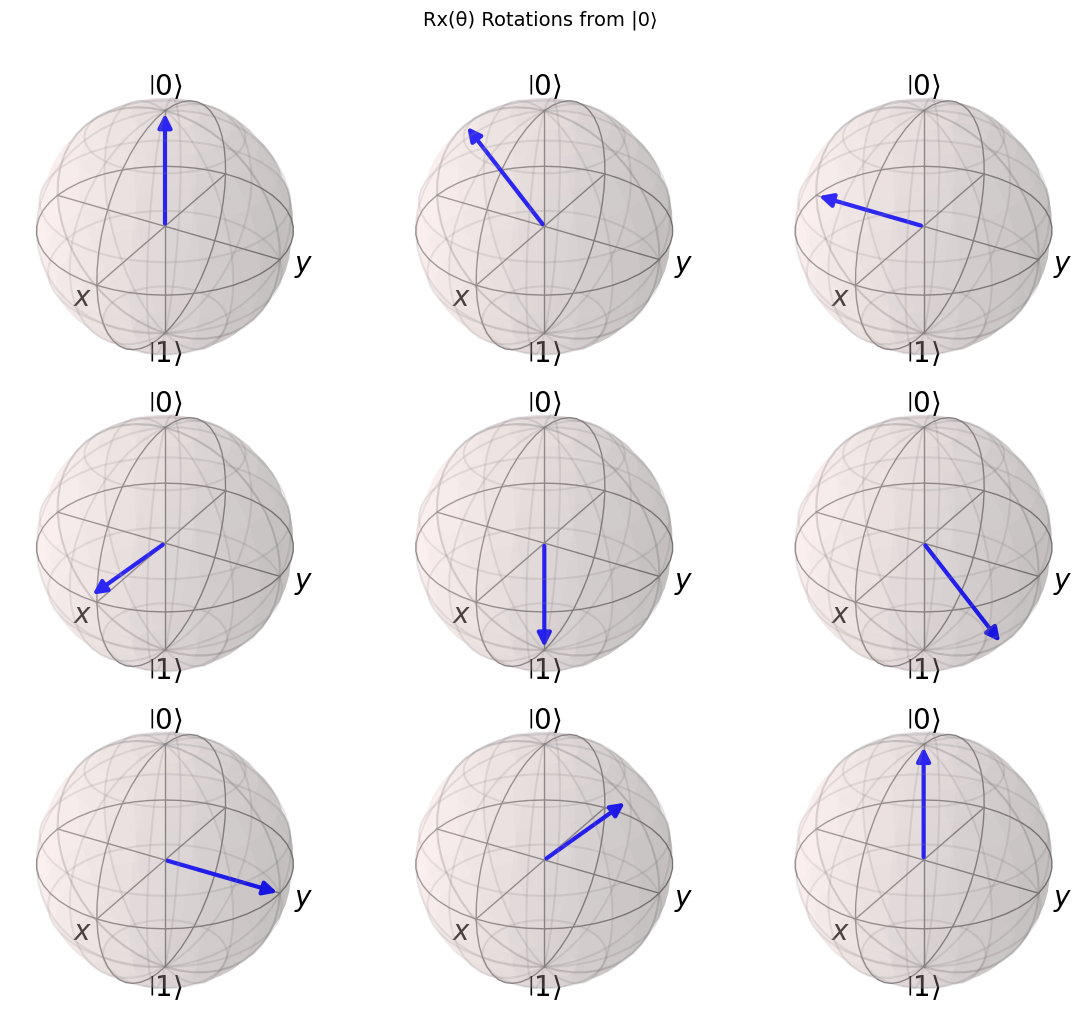


Ry(θ) rotations from |0⟩

Angle      Bloch Coordinates (x, y, z)        
--------------------------------------------------
Ry(0°  ): (+0.00, +0.00, +1.00)
Ry(45° ): (+0.71, +0.00, +0.71)
Ry(90° ): (+1.00, +0.00, +0.00)
Ry(135°): (+0.71, +0.00, -0.71)
Ry(180°): (+0.00, +0.00, -1.00)
Ry(225°): (-0.71, +0.00, -0.71)
Ry(270°): (-1.00, +0.00, -0.00)
Ry(315°): (-0.71, +0.00, +0.71)
Ry(360°): (-0.00, +0.00, +1.00)


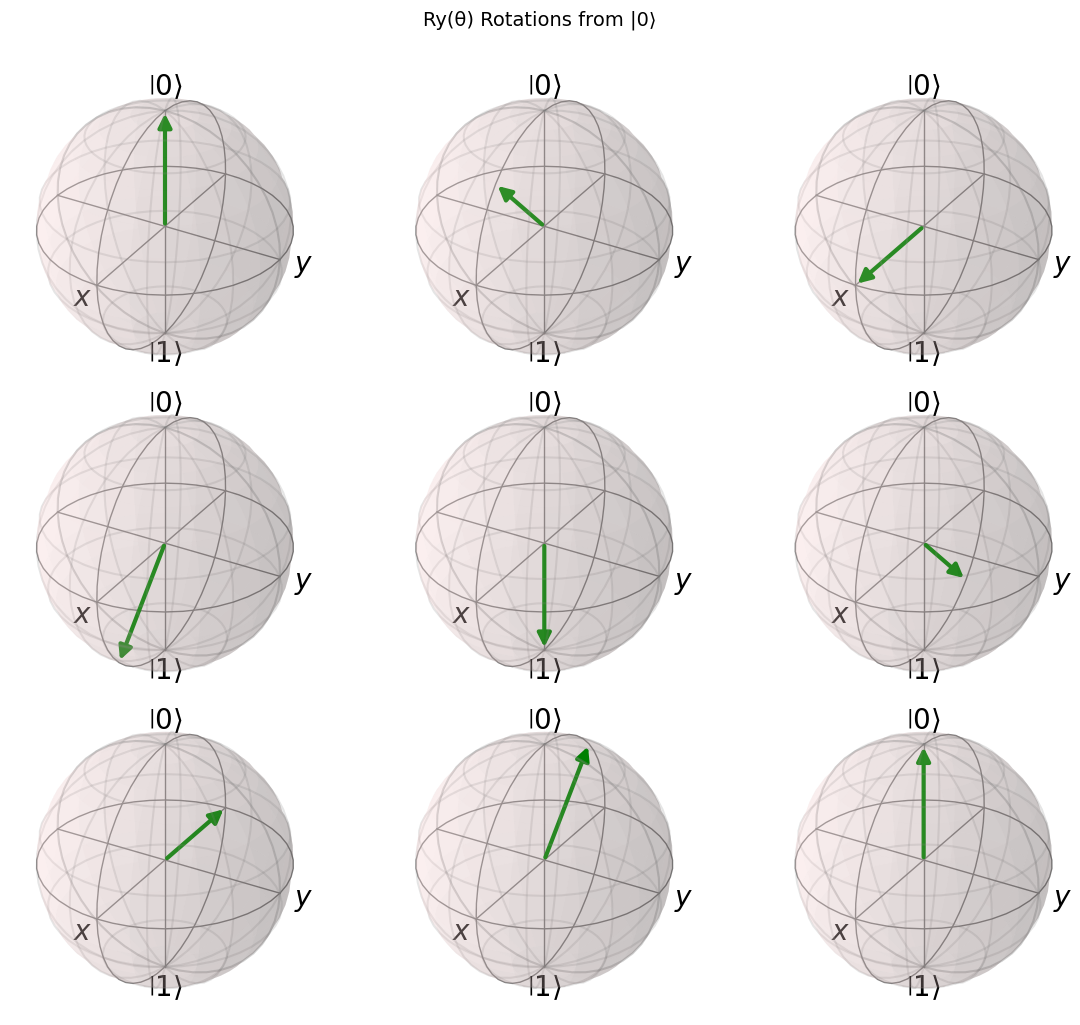


OBSERVATIONS

Rx(θ) rotations:
  - Rotates in the Y-Z plane
  - Changes y and z coordinates
  - At θ = 90°: |0⟩ → (|0⟩ - i|1⟩)/√2 (+Y axis)
  - At θ = 180°: |0⟩ → -i|1⟩ (south pole with phase -i)
  - At θ = 360°: |0⟩ → -|0⟩ (north pole with global phase -1, not |0⟩)

Ry(θ) rotations:
  - Rotates in the X-Z plane
  - Changes x and z coordinates
  - At θ = 90°: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2 (+X axis)
  - At θ = 180°: |0⟩ → |1⟩ (south pole, no phase)
  - At θ = 360°: |0⟩ → -|0⟩ (north pole with global phase -1, not |0⟩)

Key Insight: 
  - Rx and Ry create different trajectories on the Bloch sphere
  - Both can rotate the state from north pole to south pole
  - A 360° rotation returns the state to the north pole with a global phase of -1
  - A 720° rotation is needed to return to the exact same state |0⟩
  - This demonstrates that SU(2) is a double cover of SO(3)



In [19]:
# ============================================================================
# VISUALIZING ROTATION GATES ON BLOCH SPHERE
# ============================================================================

print("=" * 70)
print("VISUALIZING RX AND RY ROTATIONS")
print("=" * 70)

from qutip import gates

# Initial state |0⟩
initial = qt.basis(2, 0)

# Test angles for visualization
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi, 5*np.pi/4, 3*np.pi/2, 7*np.pi/4, 2*np.pi]
angle_labels = ["0°", "45°", "90°", "135°", "180°", "225°", "270°", "315°", "360°"]

# ============================================================================
# Rx ROTATIONS VISUALIZATION
# ============================================================================

print("\n" + "=" * 50)
print("Rx(θ) rotations from |0⟩")
print("=" * 50)

# Create figure for Rx rotations
fig_rx, axes_rx = plt.subplots(3, 3, figsize=(12, 10), subplot_kw={'projection': '3d'})
axes_rx = axes_rx.flatten()

print(f"\n{'Angle':<10} {'Bloch Coordinates (x, y, z)':<35}")
print("-" * 50)

for idx, (theta, label) in enumerate(zip(angles, angle_labels)):
    # Apply Rx gate
    state = gates.rx(theta) * initial

    # Get Bloch coordinates
    state_full = state.full().flatten()
    x = 2 * np.real(state_full[0] * np.conjugate(state_full[1]))
    y = 2 * np.imag(state_full[0] * np.conjugate(state_full[1]))
    z = np.abs(state_full[0])**2 - np.abs(state_full[1])**2

    # Plot on Bloch sphere
    bloch = qt.Bloch(fig=fig_rx, axes=axes_rx[idx])
    bloch.add_states(state)
    bloch.vector_color = ['blue']
    bloch.title = f"Rx({label})\n(x={x:.2f}, y={y:.2f}, z={z:.2f})"
    bloch.render()

    print(f"Rx({label:4}): ({x:+.2f}, {y:+.2f}, {z:+.2f})")

plt.suptitle("Rx(θ) Rotations from |0⟩", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# Ry ROTATIONS VISUALIZATION
# ============================================================================

print("\n" + "=" * 50)
print("Ry(θ) rotations from |0⟩")
print("=" * 50)

# Create figure for Ry rotations
fig_ry, axes_ry = plt.subplots(3, 3, figsize=(12, 10), subplot_kw={'projection': '3d'})
axes_ry = axes_ry.flatten()

print(f"\n{'Angle':<10} {'Bloch Coordinates (x, y, z)':<35}")
print("-" * 50)

for idx, (theta, label) in enumerate(zip(angles, angle_labels)):
    # Apply Ry gate
    state = gates.ry(theta) * initial

    # Get Bloch coordinates
    state_full = state.full().flatten()
    x = 2 * np.real(state_full[0] * np.conjugate(state_full[1]))
    y = 2 * np.imag(state_full[0] * np.conjugate(state_full[1]))
    z = np.abs(state_full[0])**2 - np.abs(state_full[1])**2

    # Plot on Bloch sphere
    bloch = qt.Bloch(fig=fig_ry, axes=axes_ry[idx])
    bloch.add_states(state)
    bloch.vector_color = ['green']
    bloch.title = f"Ry({label})\n(x={x:.2f}, y={y:.2f}, z={z:.2f})"
    bloch.render()

    print(f"Ry({label:4}): ({x:+.2f}, {y:+.2f}, {z:+.2f})")

plt.suptitle("Ry(θ) Rotations from |0⟩", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# OBSERVATIONS (CORRECTED)
# ============================================================================

print("\n" + "=" * 70)
print("OBSERVATIONS")
print("=" * 70)

print("""
Rx(θ) rotations:
  - Rotates in the Y-Z plane
  - Changes y and z coordinates
  - At θ = 90°: |0⟩ → (|0⟩ - i|1⟩)/√2 (+Y axis)
  - At θ = 180°: |0⟩ → -i|1⟩ (south pole with phase -i)
  - At θ = 360°: |0⟩ → -|0⟩ (north pole with global phase -1, not |0⟩)

Ry(θ) rotations:
  - Rotates in the X-Z plane
  - Changes x and z coordinates
  - At θ = 90°: |0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2 (+X axis)
  - At θ = 180°: |0⟩ → |1⟩ (south pole, no phase)
  - At θ = 360°: |0⟩ → -|0⟩ (north pole with global phase -1, not |0⟩)

Key Insight:
  - Rx and Ry create different trajectories on the Bloch sphere
  - Both can rotate the state from north pole to south pole
  - A 360° rotation returns the state to the north pole with a global phase of -1
  - A 720° rotation is needed to return to the exact same state |0⟩
  - This demonstrates that SU(2) is a double cover of SO(3)
""")

print("=" * 70)

## 6. Euler Angle Decomposition

### Z-Y-Z Decomposition

Any single-qubit unitary can be written as:

$$ U = e^{i\alpha} R_z(\beta) R_y(\gamma) R_z(\delta) $$

where $e^{i\alpha}$ is a global phase. This is called the **Z-Y-Z Euler decomposition**.

### Examples

All decompositions below are up to a global phase, which has no physical consequence.

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Gate</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Decomposition (up to global phase)</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Angles</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$H$</td>
            <td style="padding: 8px;">$e^{i\pi/2} R_z(\pi/2) R_y(\pi/2) R_z(\pi/2)$</td>
            <td style="padding: 8px;">$\alpha = \pi/2$, $\beta = \pi/2$, $\gamma = \pi/2$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$T$</td>
            <td style="padding: 8px;">$e^{i\pi/8} R_z(\pi/4)$</td>
            <td style="padding: 8px;">$\alpha = \pi/4$, $\beta = 0$, $\gamma = 0$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$S$</td>
            <td style="padding: 8px;">$e^{i\pi/4} R_z(\pi/2)$</td>
            <td style="padding: 8px;">$\alpha = \pi/2$, $\beta = 0$, $\gamma = 0$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$X$</td>
            <td style="padding: 8px;">$e^{i\pi/2} R_z(0) R_y(\pi) R_z(0)$</td>
            <td style="padding: 8px;">$\alpha = 0$, $\beta = \pi$, $\gamma = 0$</td>
        </tr>
    </tbody>
</table>

### Why This Matters

Many quantum computers natively implement $R_z$ and $R_y$ rotations. The Z-Y-Z decomposition allows arbitrary gates to be compiled into native operations. Since global phases are physically unobservable, the decomposition up to global phase is sufficient for all practical purposes.

### General Decomposition

Any single-qubit gate can be implemented using at most 3 rotations:

$$ U = e^{i\alpha} R_z(\beta) R_y(\gamma) R_z(\delta) $$

where $\alpha$ is a global phase.

## 7. Summary and Key Insights

### Rotation Gates Summary

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Gate</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Generator</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Matrix Form</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Action on |0⟩</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$R_x(\theta)$</td>
            <td style="padding: 8px;">$X$</td>
            <td style="padding: 8px;">$\begin{pmatrix} \cos(\theta/2) & -i\sin(\theta/2) \\ -i\sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$</td>
            <td style="padding: 8px;">Rotates towards $|1\rangle$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$R_y(\theta)$</td>
            <td style="padding: 8px;">$Y$</td>
            <td style="padding: 8px;">$\begin{pmatrix} \cos(\theta/2) & -\sin(\theta/2) \\ \sin(\theta/2) & \cos(\theta/2) \end{pmatrix}$</td>
            <td style="padding: 8px;">Rotates towards $|1\rangle$</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$R_z(\theta)$</td>
            <td style="padding: 8px;">$Z$</td>
            <td style="padding: 8px;">$\begin{pmatrix} e^{-i\theta/2} & 0 \\ 0 & e^{i\theta/2} \end{pmatrix}$</td>
            <td style="padding: 8px;">Adds phase to $|1\rangle$</td>
        </tr>
    </tbody>
</table>

### Special Cases

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Gate</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Relation</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Angle</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$X$</td>
            <td style="padding: 8px;">$i R_x(\pi)$</td>
            <td style="padding: 8px;">$\pi$ rotation around X</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$Y$</td>
            <td style="padding: 8px;">$i R_y(\pi)$</td>
            <td style="padding: 8px;">$\pi$ rotation around Y</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$Z$</td>
            <td style="padding: 8px;">$i R_z(\pi)$</td>
            <td style="padding: 8px;">$\pi$ rotation around Z</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$H$</td>
            <td style="padding: 8px;">$i R_z(\pi/2) R_y(\pi/2) R_z(\pi/2)$</td>
            <td style="padding: 8px;">Euler decomposition</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$T$</td>
            <td style="padding: 8px;">$e^{i\pi/8} R_z(\pi/4)$</td>
            <td style="padding: 8px;">$\pi/4$ rotation around Z</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$S$</td>
            <td style="padding: 8px;">$e^{i\pi/4} R_z(\pi/2)$</td>
            <td style="padding: 8px;">$\pi/2$ rotation around Z</td>
        </tr>
    </tbody>
</table>

### Key Formulas

<table style="width: 100%; border-collapse: collapse;">
    <thead>
        <tr>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Formula</th>
            <th style="text-align: left; padding: 8px; background-color: #f2f2f2;">Name</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 8px;">$R_{\vec{n}}(\theta) = e^{-i\theta \vec{n} \cdot \vec{\sigma}/2}$</td>
            <td style="padding: 8px;">General rotation</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$e^{-i\theta X/2} = \cos(\theta/2)I - i\sin(\theta/2)X$</td>
            <td style="padding: 8px;">Euler formula for X</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$e^{-i\theta Y/2} = \cos(\theta/2)I - i\sin(\theta/2)Y$</td>
            <td style="padding: 8px;">Euler formula for Y</td>
        </tr>
        <tr>
            <td style="padding: 8px;">$e^{-i\theta Z/2} = \cos(\theta/2)I - i\sin(\theta/2)Z$</td>
            <td style="padding: 8px;">Euler formula for Z</td>
        </tr>
    </tbody>
</table>

### Key Takeaways

1. **SU(2)** is the group of single-qubit gates (up to global phase)
2. **Pauli matrices** are generators of rotations (Lie algebra)
3. **Exponential map** takes generators to rotations: $R_{\vec{n}}(\theta) = e^{-i\theta \vec{n} \cdot \vec{\sigma}/2}$
4. **Rx, Ry, Rz** are continuous rotation gates with angle $\theta/2$ factor
5. **Euler decomposition** allows any gate to be built from $R_z$ and $R_y$: $U = e^{i\alpha} R_z(\beta) R_y(\gamma) R_z(\delta)$
6. **Rotation angle** determines how far the state moves on Bloch sphere
7. **Global phases** are unobservable and can be ignored physically

---

**Day 4 Complete!** 🎉

You now understand:
- The SU(2) group and its relation to qubit rotations
- The exponential map from Pauli matrices to rotation gates
- Rx, Ry, Rz gates and their matrix forms
- How to implement and visualize rotation gates
- Euler angle decomposition of arbitrary single-qubit gates

Proceed to Day 5 when ready.